<a href="https://colab.research.google.com/github/victoremanuelfont/analise_homicidios_regressao/blob/main/An%C3%A1lise_Homic%C3%ADdios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparação do Ambiente e Base de Dados
Nesta primeira etapa, vamos importar as bibliotecas necessárias para manipulação de dados (pandas e numpy) e criação de gráficos (matplotlib). Em seguida, faremos o carregamento do arquivo CSV fornecido pela UNODC e um tratamento inicial para remover dados nulos e focar apenas na métrica de contagem absoluta ("Counts"), evitando distorções com taxas proporcionais.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregando a base de dados
# O skiprows=2 pula as linhas de título/texto da UNODC para achar as colunas corretas.
df = pd.read_csv('data_cts_intentional_homicide.csv', skiprows=2, low_memory=False)

# Vamos imprimir as colunas só para garantir que o Pandas encontrou o cabeçalho certo
print("Colunas encontradas:", df.columns.tolist())

# 2. Tratamento de dados: Removendo valores nulos na coluna 'VALUE' (A UNODC costuma deixar em maiúsculo)
# Caso o print acima mostre 'Value' em minúsculo, basta alterar aqui.
coluna_valor = 'VALUE' if 'VALUE' in df.columns else 'Value'
df = df.dropna(subset=[coluna_valor])

# 3. Convertendo a coluna 'Year' (ou 'YEAR') para numérico
coluna_ano = 'YEAR' if 'YEAR' in df.columns else 'Year'
df[coluna_ano] = pd.to_numeric(df[coluna_ano], errors='coerce')

# 4. Filtrando para usar apenas a unidade de medida 'Counts'
# Identificando a coluna de unidade de medida correta
coluna_medida = 'UNIT_OF_MEASUREMENT' if 'UNIT_OF_MEASUREMENT' in df.columns else 'Unit of measurement'
df_counts = df[df[coluna_medida].str.contains('Count', na=False, case=False)]

# Padronizando os nomes das colunas essenciais para o resto do código funcionar perfeitamente
df_counts = df_counts.rename(columns={
    coluna_valor: 'Value',
    coluna_ano: 'Year',
    'COUNTRY': 'Country',
    'REGION': 'Region',
    'SUBREGION': 'Subregion',
    'SEX': 'Sex',
    'INDICATOR': 'Indicator'
})

print("\nBase de dados carregada e tratada com sucesso!")

Colunas encontradas: ['Iso3_code', 'Country', 'Region', 'Subregion', 'Indicator', 'Dimension', 'Category', 'Sex', 'Age', 'Year', 'Unit of measurement', 'VALUE', 'Source']

Base de dados carregada e tratada com sucesso!


1. Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?
Para responder a esta pergunta, filtramos os dados para o período de 2018 a 2022, agrupamos pelo nome do país e somamos os valores totais de homicídios. Por fim, extraímos os 10 maiores.

In [28]:
df_last_5 = df_counts[(df_counts['Year'] >= 2018) & (df_counts['Year'] <= 2022)]
top_10_5_anos = df_last_5.groupby('Country')['Value'].sum().nlargest(10)

print("Top 10 países com mais homicídios nos últimos 5 anos (2018-2022):")
print(top_10_5_anos)

Top 10 países com mais homicídios nos últimos 5 anos (2018-2022):
Country
Mexico                      1.493027e+06
United States of America    7.390043e+05
Brazil                      7.216940e+05
Colombia                    6.799120e+05
India                       4.711780e+05
Russian Federation          3.395290e+05
Iraq (Central Iraq)         2.187620e+05
Guatemala                   2.075090e+05
South Africa                2.073390e+05
Honduras                    2.025890e+05
Name: Value, dtype: float64


2. Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?
Aqui, aplicamos dois filtros simultâneos: o ano deve ser exatamente 2022 e a coluna 'Sex' deve conter a palavra 'Female'. Depois, repetimos a lógica de agrupamento e soma.

In [29]:
df_mulheres_2022 = df_counts[(df_counts['Year'] == 2022) & (df_counts['Sex'].str.contains('Female', na=False, case=False))]
top_10_mulheres_2022 = df_mulheres_2022.groupby('Country')['Value'].sum().nlargest(10)

print("Top 10 países com maiores índices de homicídios de mulheres em 2022:")
print(top_10_mulheres_2022)

Top 10 países com maiores índices de homicídios de mulheres em 2022:
Country
Mexico                      16448.000000
India                       16378.884088
United States of America    12079.000000
Brazil                       7542.000000
Colombia                     5982.000000
South Africa                 3914.000000
Russian Federation           3281.000000
Guatemala                    2765.000000
Türkiye                      2404.000000
Ecuador                      2295.000000
Name: Value, dtype: float64


3. Quais as regiões com mais homicídios?
Vamos agrupar todo o dataset histórico pela coluna 'Region' (que representa os continentes/grandes regiões) e somar os valores, ordenando do maior para o menor.

In [30]:
top_regioes = df_counts.groupby('Region')['Value'].sum().sort_values(ascending=False)

print("Regiões com mais homicídios (Histórico total):")
print(top_regioes)

Regiões com mais homicídios (Histórico total):
Region
Americas    1.585854e+07
Asia        6.042986e+06
Europe      3.672710e+06
Africa      1.692690e+06
Oceania     4.995545e+04
Name: Value, dtype: float64


4. Quais países com menor número de homicídios em cada subregião?
Esta pergunta exige duas etapas: primeiro, somamos os homicídios por país e subregião. Depois, encontramos o índice do valor mínimo dentro de cada subregião e exibimos o resultado.

In [31]:
# Somatório por país e subregião
sum_by_country_sub = df_counts.groupby(['Subregion', 'Country'])['Value'].sum().reset_index()

# Encontrando o menor valor por subregião
idx_min_sub = sum_by_country_sub.groupby('Subregion')['Value'].idxmin()
menor_por_subregiao = sum_by_country_sub.loc[idx_min_sub]

print("Países com menor número de homicídios em cada subregião:")
print(menor_por_subregiao[['Subregion', 'Country', 'Value']].to_string(index=False))

Países com menor número de homicídios em cada subregião:
                      Subregion                                    Country        Value
      Australia and New Zealand                                New Zealand  6638.817680
                   Central Asia                                 Kyrgyzstan  5401.000000
                   Eastern Asia China, Macao Special Administrative Region   577.000000
                 Eastern Europe                                   Slovakia 13125.000000
Latin America and the Caribbean                                 Montserrat    18.000000
                      Melanesia                                    Vanuatu     8.000000
                     Micronesia           Micronesia (Federated States of)     2.000000
                Northern Africa                                    Tunisia  5092.000000
               Northern America                  Saint Pierre and Miquelon     2.000000
                Northern Europe                              Fa

5. Quais países com menor número de morte de mulheres?
Filtramos novamente a base para incluir apenas o sexo feminino, agrupamos por país e, desta vez, utilizamos a função nsmallest para buscar os 5 países com os menores registros.

In [20]:
df_mulheres = df_counts[df_counts['Sex'].str.contains('Female', na=False, case=False)]
menor_mulheres = df_mulheres.groupby('Country')['Value'].sum().nsmallest(5)

print("Países com menor número de mortes de mulheres (Top 5):")
print(menor_mulheres)

Países com menor número de mortes de mulheres (Top 5):
Country
Gibraltar                    0.0
Holy See                     0.0
Monaco                       0.0
Saint Pierre and Miquelon    0.0
Sao Tome and Principe        0.0
Name: Value, dtype: float64


6. Quais as subregiões com maior número de homicídios?
Lógica semelhante à da Pergunta 3, mas agora agrupando pela coluna 'Subregion' e extraindo apenas os 5 maiores valores.

In [21]:
top_subregioes = df_counts.groupby('Subregion')['Value'].sum().nlargest(5)

print("Subregiões com maior número de homicídios (Top 5):")
print(top_subregioes)

Subregiões com maior número de homicídios (Top 5):
Subregion
Latin America and the Caribbean    1.249901e+07
Southern Asia                      3.199555e+06
Northern America                   2.533511e+06
Eastern Europe                     2.508899e+06
Sub-Saharan Africa                 1.487450e+06
Name: Value, dtype: float64


7. Identifique o país com maior número de homicídios em cada continente em 2020
Primeiro, isolamos os dados do ano de 2020. Depois, agrupamos por Região e País para ter a soma total. Por fim, buscamos o país com o valor máximo (idxmax) dentro de cada Região.

In [22]:
df_2020 = df_counts[df_counts['Year'] == 2020]

# Somatório por região e país em 2020
sum_2020 = df_2020.groupby(['Region', 'Country'])['Value'].sum().reset_index()

# Encontrando o índice máximo por região
idx_max_2020 = sum_2020.groupby('Region')['Value'].idxmax()
maior_2020_continente = sum_2020.loc[idx_max_2020]

print("País com maior número de homicídios por continente em 2020:")
print(maior_2020_continente[['Region', 'Country', 'Value']].to_string(index=False))

País com maior número de homicídios por continente em 2020:
  Region            Country    Value
  Africa       South Africa  19972.0
Americas             Mexico 280536.0
    Asia              India  82342.0
  Europe Russian Federation  73527.0
 Oceania          Australia   1098.0


8. Qual o país mais violento para as mulheres em 2021?
Filtramos o ano de 2021 e o sexo feminino. Somamos os valores por país e identificamos aquele com o registro máximo absoluto.

In [23]:
df_mulheres_2021 = df_counts[(df_counts['Year'] == 2021) & (df_counts['Sex'].str.contains('Female', na=False, case=False))]
soma_mulheres_2021 = df_mulheres_2021.groupby('Country')['Value'].sum()

pais_mais_violento = soma_mulheres_2021.idxmax()
total_casos = soma_mulheres_2021.max()

print(f"O país mais violento para mulheres em 2021 foi: {pais_mais_violento} com {total_casos} casos registrados.")

O país mais violento para mulheres em 2021 foi: India com 17012.3757684079 casos registrados.


9. Qual o país com maior valor de 'indicador: Victims of intentional homicide'?
Para esta pergunta, utilizamos o DataFrame original completo (sem o filtro exclusivo de 'Counts', caso a métrica do indicador exija visão geral). Procuramos a frase exata na coluna 'Indicator'.

In [24]:
# Trocando 'df' por 'df_counts' para usar as colunas padronizadas e os valores corretos
df_indicador = df_counts[df_counts['Indicator'].str.contains('Victims of intentional homicide', na=False, case=False)]

maior_indicador_pais = df_indicador.groupby('Country')['Value'].sum().idxmax()
valor_maximo = df_indicador.groupby('Country')['Value'].sum().max()

print(f"O país com o maior valor total no indicador 'Victims of intentional homicide' é: {maior_indicador_pais} (Valor: {valor_maximo})")

O país com o maior valor total no indicador 'Victims of intentional homicide' é: Brazil (Valor: 3467053.5122442413)


10. Qual a média de homicídios no Brasil nos últimos 10 anos?
Consideramos a década mais recente com dados consolidados (2013 a 2022). Filtramos o país 'Brazil', agrupamos os homicídios somados por ano e, ao final, calculamos a média aritmética desses 10 anos.

In [25]:
df_brasil = df_counts[(df_counts['Country'] == 'Brazil') & (df_counts['Year'] >= 2013) & (df_counts['Year'] <= 2022)]

# Somamos o total por ano primeiro, e depois tiramos a média desses anos
soma_anual_brasil = df_brasil.groupby('Year')['Value'].sum()
media_brasil = soma_anual_brasil.mean()

print(f"A média anual de homicídios no Brasil entre 2013 e 2022 foi de: {media_brasil:.2f}")

A média anual de homicídios no Brasil entre 2013 e 2022 foi de: 132068.80


##Definição da Estratégia de Regressão para 2023-2026
Para cumprir a exigência de Machine Learning / Regressão, utilizaremos o modelo de LinearRegression da biblioteca Scikit-Learn.Agruparemos o total global de homicídios por ano (de 2000 a 2022 para ter uma base sólida de treinamento).Treinaremos o modelo usando os Anos como variável independente ($X$) e a Contagem de Homicídios como variável dependente ($y$).Faremos a predição para os anos de 2023, 2024, 2025 e 2026.Por fim, plotaremos um gráfico de linhas para visualizar a tendência histórica unida à previsão futura.

--- RESULTADOS DA PREDIÇÃO (2023 - 2026) ---
   Year  Predicao_Homicidios
0  2023         1.345891e+06
1  2024         1.387062e+06
2  2025         1.428232e+06
3  2026         1.469402e+06


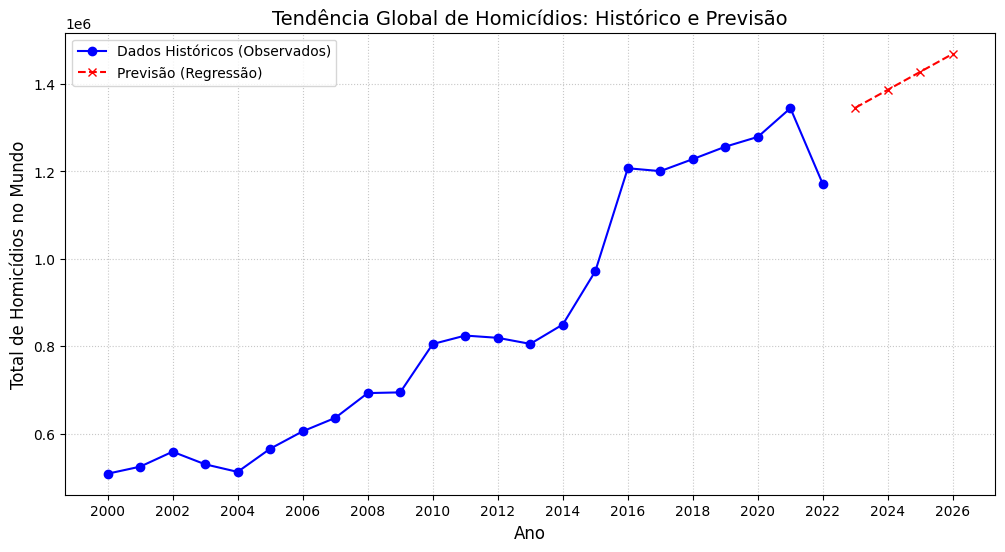

In [26]:
from sklearn.linear_model import LinearRegression

# 1. Preparação dos dados para o modelo (Total global de homicídios por ano)
df_tendencia = df_counts.groupby('Year')['Value'].sum().reset_index()

# Filtrando um período consistente para treinamento (anos 2000 até 2022)
df_tendencia = df_tendencia[(df_tendencia['Year'] >= 2000) & (df_tendencia['Year'] <= 2022)]

# 2. Definição das variáveis
X = df_tendencia[['Year']] # O Scikit-Learn exige um formato de dataframe (2D) para X
y = df_tendencia['Value']  # Variável alvo (target)

# 3. Inicialização e Treinamento do Modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X, y)

# 4. Criando os anos que queremos prever
anos_futuros = pd.DataFrame({'Year': [2023, 2024, 2025, 2026]})

# Fazendo as predições
predicoes = modelo.predict(anos_futuros)
anos_futuros['Predicao_Homicidios'] = predicoes

print("--- RESULTADOS DA PREDIÇÃO (2023 - 2026) ---")
print(anos_futuros)

# 5. Visualização Gráfica
plt.figure(figsize=(12, 6))

# Plotando os dados reais históricos
plt.plot(X['Year'], y, label='Dados Históricos (Observados)', marker='o', color='blue')

# Plotando as predições do modelo
plt.plot(anos_futuros['Year'], anos_futuros['Predicao_Homicidios'], label='Previsão (Regressão)', marker='x', color='red', linestyle='--')

plt.title('Tendência Global de Homicídios: Histórico e Previsão', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Homicídios no Mundo', fontsize=12)
plt.xticks(np.arange(2000, 2027, 2)) # Ajustando o eixo X para facilitar a leitura
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Exibindo o gráfico
plt.show()